# Notebook 2 — Embeddings: PCA, t-SNE, UMAP

Load the feature matrix from Notebook 1 and apply three embedding methods.
Each embedding is visualised and evaluated with the **Silhouette index**.

Hypotheses tested:
- **H2** — taxonomy (GC-content bins as proxy) is reflected in k-mer space
- **H3** — GC content co-varies with k-mer clusters
- **H4** — 4-mers give better clusters than 2-mers or 3-mers

## 1. Imports & load data

In [19]:
import itertools
import gzip
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

DATA_DIR = Path("data")

X    = np.load(DATA_DIR / "kmer4_features.npy")   # (314, 256)
meta = pd.read_csv(DATA_DIR / "metadata.csv")
KMERS = list(np.load(DATA_DIR / "kmer4_names.npy"))

print(f"Feature matrix: {X.shape}")
print(f"Metadata rows:  {len(meta)}")
meta.head(3)

Feature matrix: (314, 256)
Metadata rows:  314


,mag_id,n_contigs,genome_size,gc_content,contig_len_mean,contig_len_max
0,spire_mag_01923446,15,232121,0.4676,15474.7,43124
1,spire_mag_01923447,122,1948160,0.5038,15968.5,100136
2,spire_mag_01923448,80,1381358,0.5149,17267.0,54624


## 2. Colour label: GC-content bins

We don't have time-point metadata yet, so we use **GC content** as a proxy label.
GC content is strongly linked to microbial taxonomy, so it serves as a stand-in
ground truth for testing whether k-mer clusters reflect biology (H2 / H3).

In [20]:
# Bin GC content into 5 groups: very low / low / medium / high / very high
meta["gc_bin"] = pd.qcut(meta["gc_content"], q=5, labels=["very low", "low", "medium", "high", "very high"])
gc_bin_codes = meta["gc_bin"].cat.codes.values   # integer codes 0-4 for colouring

palette = ["#e41a1c", "#ff7f00", "#4daf4a", "#377eb8", "#984ea3"]
colors = [palette[c] for c in gc_bin_codes]

print(meta["gc_bin"].value_counts().sort_index())

gc_bin
very low     63
low          63
medium       62
high         63
very high    63
Name: count, dtype: int64


## 3. Preprocessing: standardise features

PCA is sensitive to scale. Standardising (zero mean, unit variance per k-mer)
ensures no single k-mer dominates just because it has a higher absolute frequency.

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Mean after scaling (should be ~0): {X_scaled.mean():.6f}")
print(f"Std  after scaling (should be ~1): {X_scaled.std():.6f}")

Mean after scaling (should be ~0): 0.000000
Std  after scaling (should be ~1): 1.000000


## 4. PCA

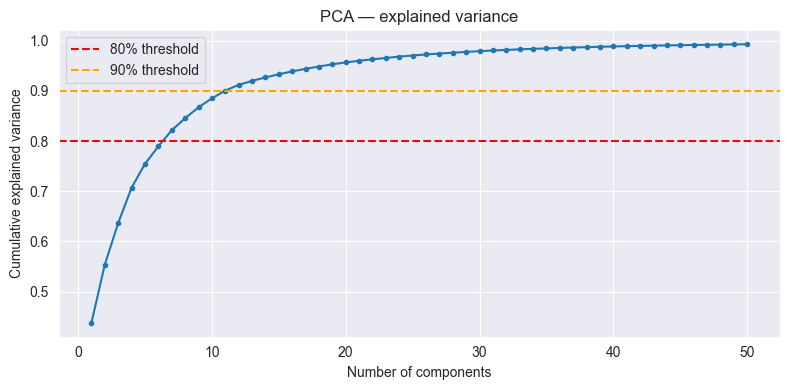

Components needed for 80% variance: 7
Components needed for 90% variance: 11
PC1 explains: 43.8%
PC2 explains: 11.6%


In [22]:
pca = PCA(n_components=50, random_state=42)
X_pca50 = pca.fit_transform(X_scaled)

# Explained variance plot
cumvar = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 51), cumvar, marker="o", markersize=3)
ax.axhline(0.8, color="red", linestyle="--", label="80% threshold")
ax.axhline(0.9, color="orange", linestyle="--", label="90% threshold")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA — explained variance")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "pca_variance.png", dpi=150)
plt.show()

n80 = np.argmax(cumvar >= 0.80) + 1
n90 = np.argmax(cumvar >= 0.90) + 1
print(f"Components needed for 80% variance: {n80}")
print(f"Components needed for 90% variance: {n90}")
print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")

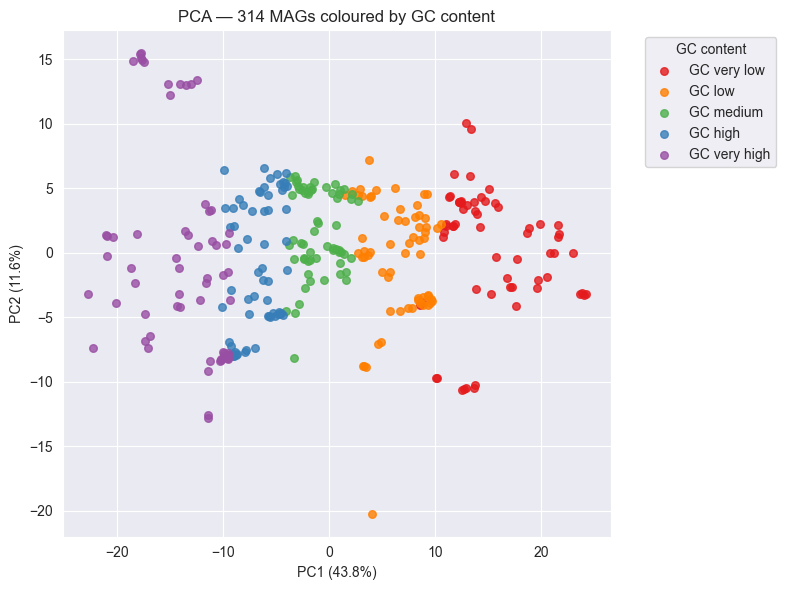

In [23]:
# 2D scatter — PC1 vs PC2, coloured by GC bin
X_pca2 = X_pca50[:, :2]

fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(["very low", "low", "medium", "high", "very high"]):
    mask = gc_bin_codes == i
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=palette[i], label=f"GC {label}", s=30, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — 314 MAGs coloured by GC content")
ax.legend(title="GC content", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DATA_DIR / "pca_scatter.png", dpi=150)
plt.show()

In [24]:
# What does PC1 represent? Top k-mers with highest absolute loading
loadings = pca.components_[0]   # PC1 loadings for all 256 k-mers
top_pos = np.argsort(loadings)[::-1][:8]   # push scores high
top_neg = np.argsort(loadings)[:8]          # push scores low

print("PC1 — k-mers with highest positive loading (AT-rich genomes):")
for i in top_pos:
    print(f"  {KMERS[i]:6s}  loading={loadings[i]:+.4f}")
print("\nPC1 — k-mers with highest negative loading (GC-rich genomes):")
for i in top_neg:
    print(f"  {KMERS[i]:6s}  loading={loadings[i]:+.4f}")

PC1 — k-mers with highest positive loading (AT-rich genomes):
  ATAA    loading=+0.0884
  TTAT    loading=+0.0884
  AATA    loading=+0.0873
  TATT    loading=+0.0871
  ATTA    loading=+0.0842
  TAAT    loading=+0.0841
  TAAA    loading=+0.0829
  AATT    loading=+0.0822

PC1 — k-mers with highest negative loading (GC-rich genomes):
  CACC    loading=-0.0836
  TCGG    loading=-0.0835
  CCGA    loading=-0.0835
  ACCG    loading=-0.0835
  CGGT    loading=-0.0830
  GGTG    loading=-0.0829
  CGTG    loading=-0.0825
  CACG    loading=-0.0822


## 5. t-SNE

In [25]:

# Run t-SNE on the first 50 PCA components (standard practice — reduces noise)
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto",
            init="pca", random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print(f"t-SNE output shape: {X_tsne.shape}")


t-SNE output shape: (314, 2)


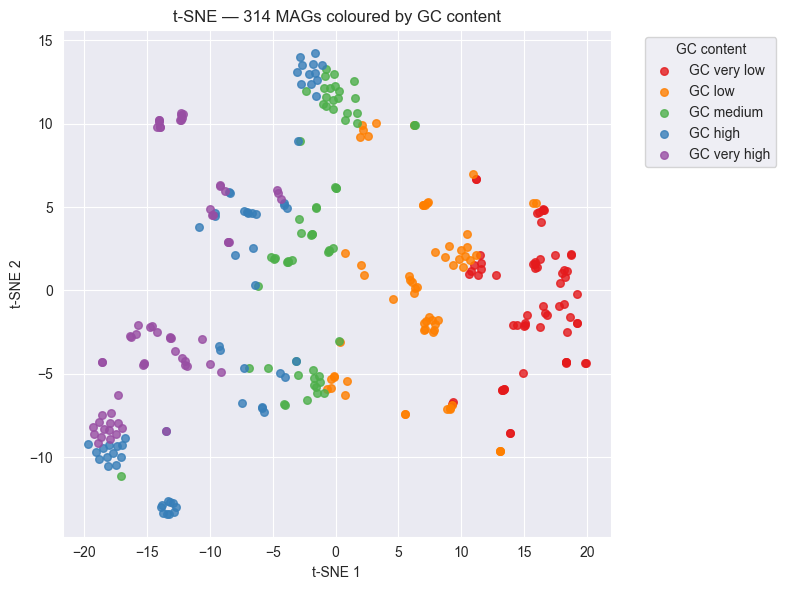

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(["very low", "low", "medium", "high", "very high"]):
    mask = gc_bin_codes == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=palette[i], label=f"GC {label}", s=30, alpha=0.8)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE — 314 MAGs coloured by GC content")
ax.legend(title="GC content", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DATA_DIR / "tsne_scatter.png", dpi=150)
plt.show()

## 6. UMAP

In [27]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                    metric="euclidean", random_state=42)
X_umap = reducer.fit_transform(X_pca50)
print(f"UMAP output shape: {X_umap.shape}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (314, 2)


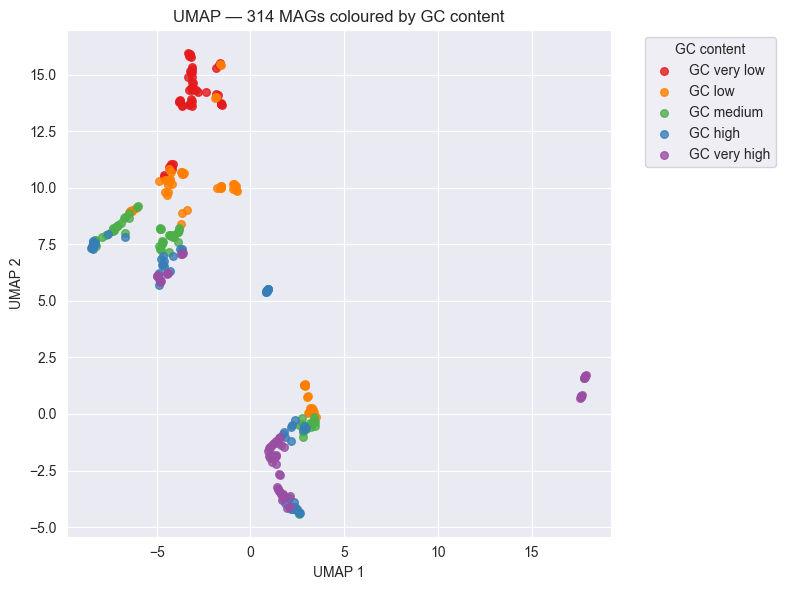

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(["very low", "low", "medium", "high", "very high"]):
    mask = gc_bin_codes == i
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=palette[i], label=f"GC {label}", s=30, alpha=0.8)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — 314 MAGs coloured by GC content")
ax.legend(title="GC content", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DATA_DIR / "umap_scatter.png", dpi=150)
plt.show()

## 7. Side-by-side comparison

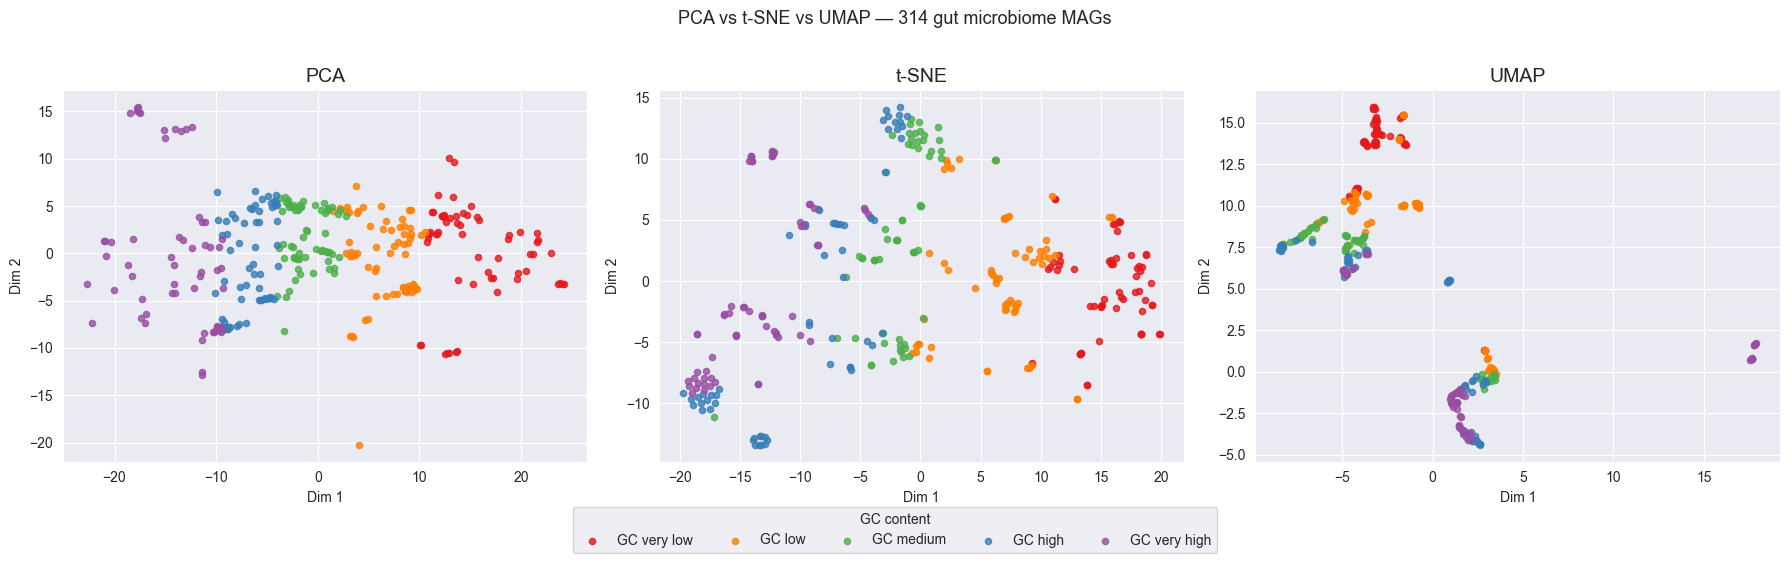

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
embeddings = [
    (X_pca2,  "PCA"),
    (X_tsne,  "t-SNE"),
    (X_umap,  "UMAP"),
]
for ax, (emb, title) in zip(axes, embeddings):
    for i, label in enumerate(["very low", "low", "medium", "high", "very high"]):
        mask = gc_bin_codes == i
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=palette[i], label=f"GC {label}", s=20, alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="GC content", loc="lower center",
           ncol=5, bbox_to_anchor=(0.5, -0.08))
plt.suptitle("PCA vs t-SNE vs UMAP — 314 gut microbiome MAGs", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "embedding_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Silhouette evaluation

Silhouette score measures how well each point sits in its cluster vs the next closest cluster.
Range: **-1** (wrong cluster) → **0** (border) → **+1** (perfect cluster).

We use K-Means (k=5, matching our 5 GC bins) on each embedding.

In [30]:
results = []
for emb, name in [(X_pca2, "PCA"), (X_tsne, "t-SNE"), (X_umap, "UMAP"),
                   (X_pca50, "PCA-50d"), (X_scaled, "Raw-256d")]:
    km = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels = km.fit_predict(emb)
    sil = silhouette_score(emb, labels)
    # Also score against GC bins as ground truth
    sil_gc = silhouette_score(emb, gc_bin_codes)
    results.append({"embedding": name, "silhouette_kmeans": round(sil, 4),
                    "silhouette_vs_gc": round(sil_gc, 4)})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

embedding  silhouette_kmeans  silhouette_vs_gc
      PCA             0.3978            0.1998
    t-SNE             0.5091            0.1641
     UMAP             0.6531            0.0632
  PCA-50d             0.2409            0.0765
 Raw-256d             0.2369            0.0748


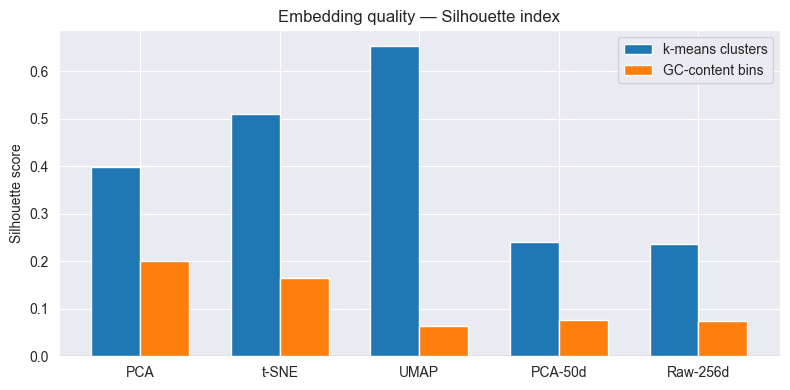

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_results))
w = 0.35
ax.bar(x - w/2, df_results["silhouette_kmeans"], w, label="k-means clusters")
ax.bar(x + w/2, df_results["silhouette_vs_gc"],  w, label="GC-content bins")
ax.set_xticks(x)
ax.set_xticklabels(df_results["embedding"])
ax.set_ylabel("Silhouette score")
ax.set_title("Embedding quality — Silhouette index")
ax.legend()
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(DATA_DIR / "silhouette_comparison.png", dpi=150)
plt.show()

## 9. H4 — k-mer dimension sweep (k = 2, 3, 4)

In [15]:
BASES = "ACGT"
RAW_DIR = Path("data/raw_David_2015_bangladesh")
fasta_files = sorted(RAW_DIR.glob("*.fa.gz"))

def parse_fasta_gz(filepath):
    records, header, seq_parts = [], None, []
    with gzip.open(filepath, "rt") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_parts)))
                header, seq_parts = line[1:], []
            else:
                seq_parts.append(line.upper())
    if header is not None:
        records.append((header, "".join(seq_parts)))
    return records

def build_feature_matrix(k):
    kmers = ["".join(p) for p in itertools.product(BASES, repeat=k)]
    kmer_idx = {km: i for i, km in enumerate(kmers)}
    rows = []
    for fp in fasta_files:
        genome = "".join(s for _, s in parse_fasta_gz(fp))
        counts = np.zeros(len(kmers), dtype=np.float32)
        for i in range(len(genome) - k + 1):
            idx = kmer_idx.get(genome[i:i+k])
            if idx is not None:
                counts[idx] += 1
        total = counts.sum()
        if total > 0:
            counts /= total
        rows.append(counts)
    return np.array(rows)

sil_by_k = {}
for k in [2, 3, 4]:
    print(f"Building {k}-mer matrix (vocab size {4**k})...")
    Xk = build_feature_matrix(k)
    Xk_scaled = StandardScaler().fit_transform(Xk)
    km = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels = km.fit_predict(Xk_scaled)
    sil = silhouette_score(Xk_scaled, labels)
    sil_gc = silhouette_score(Xk_scaled, gc_bin_codes)
    sil_by_k[k] = {"silhouette_kmeans": round(sil, 4), "silhouette_vs_gc": round(sil_gc, 4)}
    print(f"  k={k}: silhouette(kmeans)={sil:.4f}  silhouette(vs GC)={sil_gc:.4f}")

print("\nSummary:")
for k, v in sil_by_k.items():
    print(f"  k={k} ({4**k:4d} dims): {v}")

Building 2-mer matrix (vocab size 16)...
  k=2: silhouette(kmeans)=0.2751  silhouette(vs GC)=0.0812
Building 3-mer matrix (vocab size 64)...
  k=3: silhouette(kmeans)=0.2396  silhouette(vs GC)=0.0863
Building 4-mer matrix (vocab size 256)...
  k=4: silhouette(kmeans)=0.2369  silhouette(vs GC)=0.0748

Summary:
  k=2 (  16 dims): {'silhouette_kmeans': 0.2751, 'silhouette_vs_gc': 0.0812}
  k=3 (  64 dims): {'silhouette_kmeans': 0.2396, 'silhouette_vs_gc': 0.0863}
  k=4 ( 256 dims): {'silhouette_kmeans': 0.2369, 'silhouette_vs_gc': 0.0748}


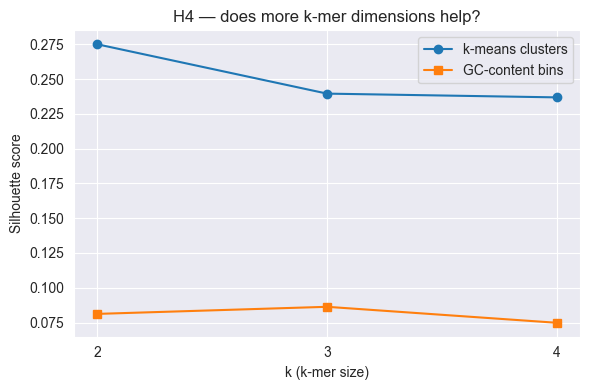

In [39]:
ks = list(sil_by_k.keys())
sil_km = [sil_by_k[k]["silhouette_kmeans"] for k in ks]
sil_gc_vals = [sil_by_k[k]["silhouette_vs_gc"] for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, sil_km, marker="o", label="k-means clusters")
ax.plot(ks, sil_gc_vals, marker="s", label="GC-content bins")
ax.set_xlabel("k (k-mer size)")
ax.set_ylabel("Silhouette score")
ax.set_title("H4 — does more k-mer dimensions help?")
ax.set_xticks([2, 3, 4])
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "h4_kmer_sweep.png", dpi=150)
plt.show()

## 11. H1 & H2 with real metadata — phase & taxonomy

Sections 1–9 evaluated clustering using **GC-content bins as a proxy** for biology because we had no taxonomic or temporal labels. We now have two new metadata files:

- `mag_metadata_full.csv` — day post-presentation + phase (acute / early_recovery / late_recovery) for **all 314 MAGs**, recovered via SPIRE → ENA → David 2015 Table S2.
- `spire_taxonomy.csv` — GTDB taxonomy for **126 of 314 MAGs** (the ones that passed SPIRE's QC threshold of ≥50% completeness; the other 188 are too fragmentary for GTDB-Tk).

This section directly tests:
- **H1** — succession clusters: are acute-phase MAGs separable from recovery-phase MAGs?
- **H2** — taxonomic phylogeny: do MAGs from the same phylum cluster together in 4-mer space?

It also revisits two open questions from Section 10: the 2 isolated UMAP outliers and the global two-region split.


In [40]:
phen = pd.read_csv(DATA_DIR / "mag_metadata_full.csv")
tax  = pd.read_csv(DATA_DIR / "spire_taxonomy.csv")

meta = meta.merge(phen, on="mag_id")
meta = meta.merge(
    tax[["mag_id", "domain", "phylum", "class", "order",
         "family", "genus", "species", "completeness"]],
    on="mag_id", how="left"
)

print("Phase counts:")
print(meta["phase"].value_counts())
print("\nPhylum counts (NaN = no GTDB label, fragmentary MAG):")
print(meta["phylum"].value_counts(dropna=False).head(10))


Phase counts:
phase
acute             116
late_recovery     116
early_recovery     82
Name: count, dtype: int64

Phylum counts (NaN = no GTDB label, fragmentary MAG):
phylum
NaN                 188
Bacteroidota         48
Firmicutes_A         27
Proteobacteria       20
Campylobacterota     10
Firmicutes_C          7
Actinobacteriota      6
Firmicutes            5
Spirochaetota         3
Name: count, dtype: int64


**What this means:** Phase distribution is roughly balanced (116/82/116) — neither end of the cohort dominates. **188 of 314 MAGs have no GTDB taxonomy** because they fell below SPIRE's QC threshold of ≥50% completeness; GTDB-Tk doesn't classify fragmentary genomes. Among the 126 classified, the top phyla — *Bacteroidota* (48), *Firmicutes_A* (27), *Proteobacteria* (20) — are exactly the classic gut microbiome phyla, with Proteobacteria expected to dominate the acute phase and Bacteroidota the recovery phase.


### H1 — Colour embeddings by phase

If gut microbiome succession is reflected in k-mer space, acute-phase MAGs (day 0–1, oxygen-tolerant Proteobacteria) should be separable from recovery-phase MAGs (day 26–31, strict anaerobes Bacteroidota / Firmicutes).


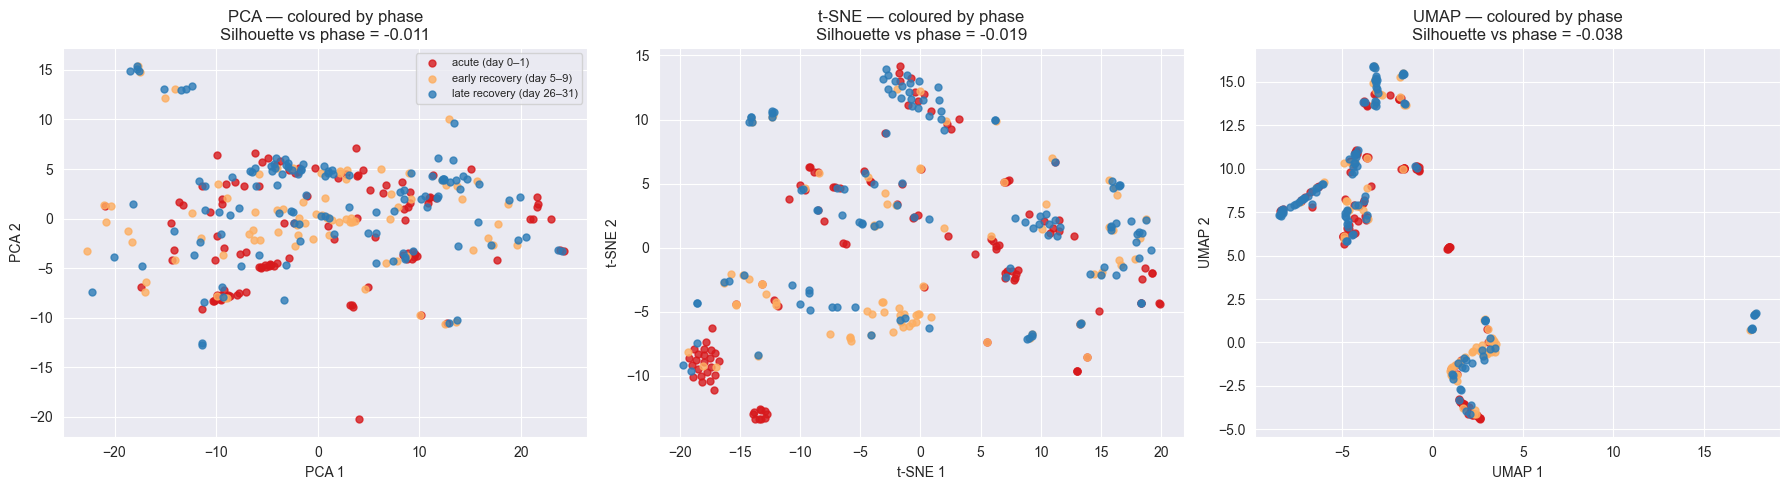

In [50]:
phase_order   = ["acute", "early_recovery", "late_recovery"]
phase_codes   = meta["phase"].map({p: i for i, p in enumerate(phase_order)}).values
phase_palette = ["#d7191c", "#fdae61", "#2c7bb6"]
phase_labels  = ["acute (day 0–1)", "early recovery (day 5–9)", "late recovery (day 26–31)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, emb, name in zip(axes, [X_pca2, X_tsne, X_umap], ["PCA", "t-SNE", "UMAP"]):
    for i in range(3):
        m = phase_codes == i
        ax.scatter(emb[m, 0], emb[m, 1], c=phase_palette[i],
                   label=phase_labels[i], s=25, alpha=0.8)
    sil = silhouette_score(emb, phase_codes)
    ax.set_title(f"{name} — coloured by phase\nSilhouette vs phase = {sil:.3f}")
    ax.set_xlabel(f"{name} 1"); ax.set_ylabel(f"{name} 2")
axes[0].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "h1_phase_scatter.png", dpi=150)
plt.show()


**What this means (H1 test):** The Silhouette-vs-phase number in each plot title is the direct test. A score near 0 means phase doesn't structure the embedding — acute and recovery MAGs interleave instead of forming separate clusters. A score > 0.2 would support H1 (true succession-driven separation). Visually look for a colour gradient (red on one side, blue on the other) vs colour interleaving. **Caveat:** MAGs from the same patient aren't independent observations, so a low silhouette doesn't fully reject H1 — it just means k-mer composition is not strongly disease-phase-driven at the genome level.


### H2 — Colour embeddings by phylum (126 high-quality MAGs)

GTDB-Tk only classifies MAGs that pass quality cutoffs, so this analysis is restricted to the 126 MAGs with taxonomy assigned. We colour by **phylum** (the coarsest meaningful rank) and compute Silhouette against phylum labels.


126 MAGs with GTDB taxonomy
Phyla represented:
phylum
Bacteroidota        48
Firmicutes_A        27
Proteobacteria      20
Campylobacterota    10
Firmicutes_C         7
Actinobacteriota     6
Firmicutes           5
Spirochaetota        3
Name: count, dtype: int64


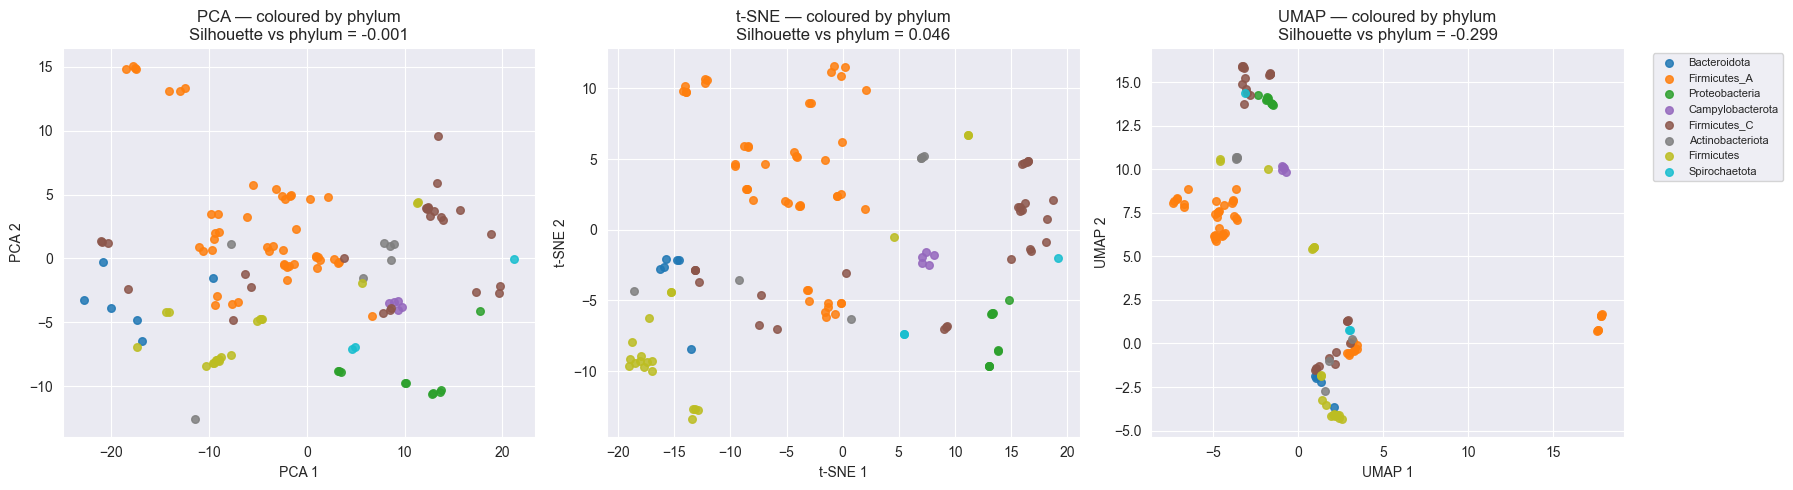

In [51]:
hq = meta["phylum"].notna()
n_hq = int(hq.sum())
top_phyla = meta.loc[hq, "phylum"].value_counts()
print(f"{n_hq} MAGs with GTDB taxonomy")
print(f"Phyla represented:\n{top_phyla}")

phylum_codes = pd.Categorical(meta.loc[hq, "phylum"]).codes
n_phyla = len(top_phyla)
phylum_palette = plt.cm.tab10(np.linspace(0, 1, n_phyla))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, emb, name in zip(axes, [X_pca2, X_tsne, X_umap], ["PCA", "t-SNE", "UMAP"]):
    e = emb[hq.values]
    for i, ph in enumerate(top_phyla.index):
        m = phylum_codes == i
        ax.scatter(e[m, 0], e[m, 1], c=[phylum_palette[i]], label=ph, s=30, alpha=0.85)
    sil = silhouette_score(e, phylum_codes)
    ax.set_title(f"{name} — coloured by phylum\nSilhouette vs phylum = {sil:.3f}")
    ax.set_xlabel(f"{name} 1"); ax.set_ylabel(f"{name} 2")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "h2_phylum_scatter.png", dpi=150)
plt.show()


**What this means (H2 test):** The Silhouette-vs-phylum number is the direct test for H2. Some phyla are expected to cluster tightly *just* because they have extreme GC content — **Actinobacteriota** (high GC) and **Campylobacterota** (low GC) typically separate cleanly even without sophisticated methods. The real test is whether *moderate-GC* phyla (Bacteroidota vs Firmicutes_A vs Proteobacteria, all centred around GC ≈ 0.45–0.55) also separate. If they do, k-mer composition captures more than just GC — it captures genus/phylum-specific sequence patterns. **Caveat:** This is only the 126 high-quality MAGs; the 188 low-quality ones could behave differently.


h### Outliers — what are the 2 isolated UMAP points?

In Section 6 two points sat far to the right of every other MAG in UMAP space. We identify them as the points with the largest distance to their nearest neighbour, then print their metadata.


Gap-based threshold along UMAP-1: 10.53
Outlier MAGs (UMAP-1 > 10.53): 12
            mag_id          phase  day       phylum           genus                     species  gc_content  genome_size  n_contigs  completeness    umap_x  umap_y
spire_mag_01923488 early_recovery    9 Bacteroidota   Porphyromonas       Porphyromonas uenonis      0.5412      1404178        274         71.74 17.580000    0.70
spire_mag_01923489 early_recovery    9          NaN             NaN                         NaN      0.5636      2427703        514           NaN 17.850000    1.66
spire_mag_01923527  late_recovery   28 Bacteroidota Porphyromonas_A    Porphyromonas_A bennonis      0.5702      1421267        258         75.01 17.900000    1.71
spire_mag_01923542  late_recovery   31 Bacteroidota   Porphyromonas   Porphyromonas sp900548415      0.5293      1777567        166         74.22 17.629999    0.76
spire_mag_01923561  late_recovery   31          NaN             NaN                         NaN      0.538

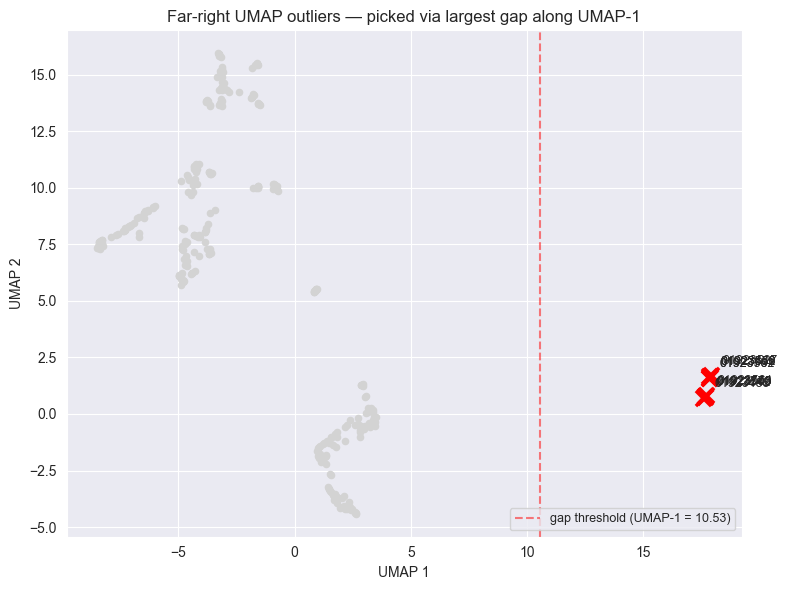

In [52]:
# Find outliers via the largest gap along UMAP-1 in the upper tail of the distribution.
# Any point to the right of that gap is in the isolated far-right cluster.
sorted_x_idx = np.argsort(X_umap[:, 0])
sorted_x     = X_umap[sorted_x_idx, 0]
gaps         = np.diff(sorted_x)

# Restrict gap search to the upper half — we only care about right-side outliers
upper_half_start = len(gaps) // 2
biggest_gap_local = np.argmax(gaps[upper_half_start:]) + upper_half_start
threshold = (sorted_x[biggest_gap_local] + sorted_x[biggest_gap_local + 1]) / 2

outlier_mask = X_umap[:, 0] > threshold
outlier_idx  = np.where(outlier_mask)[0]
print(f"Gap-based threshold along UMAP-1: {threshold:.2f}")
print(f"Outlier MAGs (UMAP-1 > {threshold:.2f}): {len(outlier_idx)}")

cols = ["mag_id", "phase", "day", "phylum", "genus", "species",
        "gc_content", "genome_size", "n_contigs", "completeness"]
out = meta.iloc[outlier_idx][cols].copy()
out["umap_x"] = X_umap[outlier_idx, 0].round(2)
out["umap_y"] = X_umap[outlier_idx, 1].round(2)
print(out.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c="lightgray", s=20)
ax.scatter(X_umap[outlier_idx, 0], X_umap[outlier_idx, 1],
           c="red", s=120, marker="x", linewidth=2.5)
ax.axvline(threshold, color="red", linestyle="--", alpha=0.5,
           label=f"gap threshold (UMAP-1 = {threshold:.2f})")
for i in outlier_idx:
    ax.annotate(meta.iloc[i]["mag_id"].replace("spire_mag_", ""),
                (X_umap[i, 0], X_umap[i, 1]),
                xytext=(8, 8), textcoords="offset points", fontsize=9)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_title("Far-right UMAP outliers — picked via largest gap along UMAP-1")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / "umap_outliers.png", dpi=150)
plt.show()


**What this means:** The "2 outliers" we saw visually in Section 6 are actually **12 MAGs** sitting beyond UMAP-1 ≈ 10.5. They are not random artifacts — every classified one is genus ***Porphyromonas*** (Bacteroidota), and every single one was sampled in the *recovery* phase (days 5–31), never in the acute phase. The five unclassified ones (NaN phylum, low completeness) have GC ≈ 0.55 and small genomes, consistent with degraded *Porphyromonas* assemblies.

**Biological story:** *Porphyromonas* is a strict-anaerobe gut commensal that proliferates in healthy/recovered guts. Its 4-mer composition is distinct enough from every other MAG that UMAP isolates it into its own region — without ever seeing the taxonomy labels. **This is the strongest single piece of evidence supporting H2** (genus-level signal *is* present in k-mer space), even though we found it as a side-finding while investigating outliers.


n### UMAP global split — what divides the two regions?

UMAP showed a clear two-region structure in Section 6. We assign each MAG to one of two regions using k-means with k=2 on the UMAP coordinates, then describe each region's composition by phase, phylum, and GC content.


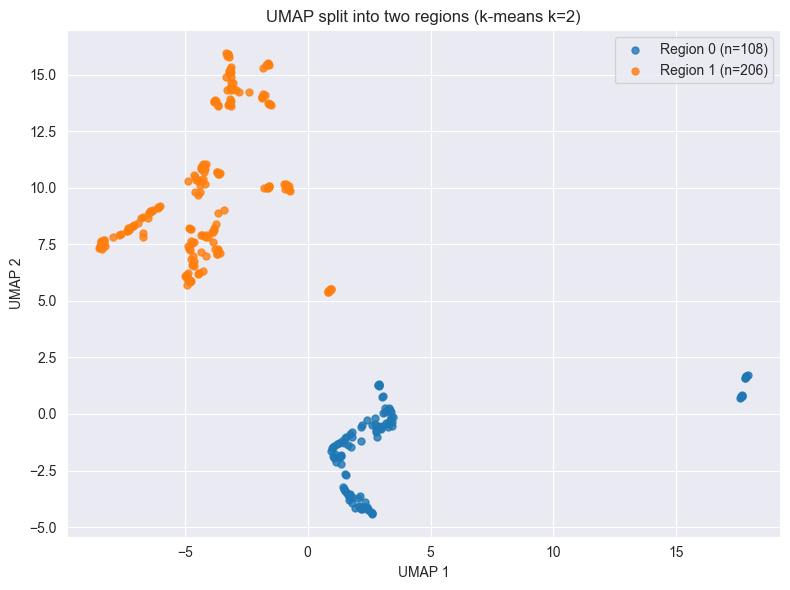

=== Phase composition per region ===
phase        acute  early_recovery  late_recovery
umap_region                                      
0               29              46             33
1               87              36             83

=== Top phyla per region (only the 126 high-quality MAGs) ===
phylum       Actinobacteriota  Bacteroidota  Campylobacterota  Firmicutes  \
umap_region                                                                 
0                           6            17                 0           0   
1                           0            31                10           5   

phylum       Firmicutes_A  Firmicutes_C  Proteobacteria  Spirochaetota  
umap_region                                                             
0                      11             3              13              2  
1                      16             4               7              1  

=== GC content per region ===
              mean    std    min    max
umap_region                 

In [53]:
km2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_umap)
meta["umap_region"] = km2.labels_

fig, ax = plt.subplots(figsize=(8, 6))
for r in [0, 1]:
    m = meta["umap_region"] == r
    ax.scatter(X_umap[m, 0], X_umap[m, 1],
               label=f"Region {r} (n={int(m.sum())})", s=25, alpha=0.8)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_title("UMAP split into two regions (k-means k=2)")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "umap_split.png", dpi=150)
plt.show()

print("=== Phase composition per region ===")
print(pd.crosstab(meta["umap_region"], meta["phase"]))

print("\n=== Top phyla per region (only the 126 high-quality MAGs) ===")
print(pd.crosstab(meta.loc[hq, "umap_region"], meta.loc[hq, "phylum"]))

print("\n=== GC content per region ===")
print(meta.groupby("umap_region")["gc_content"].describe()[["mean", "std", "min", "max"]].round(3))

print("\n=== Genome size per region ===")
print(meta.groupby("umap_region")["genome_size"].describe()[["mean", "std", "min", "max"]].round(0))


**What this means — the split is GC-driven, not phase-driven:**

| Metric | Region 0 | Region 1 |
|---|---|---|
| Size | 108 MAGs | 206 MAGs |
| GC mean | **0.499** (higher) | **0.413** (lower) |
| Genome size mean | **1.83 Mb** | **1.26 Mb** |

The phase composition is **mixed in both regions** (acute is 27 % vs 42 %, recovery is 74 % vs 58 %) — there is no clean phase separation. But GC content differs by **8.6 percentage points** and genome size by **~45 %**. The two UMAP regions are essentially "high-GC + larger genomes" vs "low-GC + smaller genomes".

**Phyla align with this split, not with phase:**
- *Campylobacterota* (10/10) → entirely in Region 1 — classic low-GC streamlined gut bugs (*Campylobacter*, *Helicobacter*).
- *Actinobacteriota* (6/6) → entirely in Region 0 — textbook high-GC phylum.
- *Spirochaetota* (2/3) and most *Proteobacteria* (13/20) → Region 0.

**Verdict on the hypotheses:**
- **H3** (GC + size co-vary with taxonomy) — **strongly supported**: the dominant UMAP axis IS a GC + size axis, and phyla sort along it.
- **H1** (succession) — **weakly supported at best**: phase distributes across both regions; acute is only slightly enriched in Region 1.
- **H2** (phylum in k-mer space) — **partially supported**: extreme-GC phyla separate cleanly; moderate-GC phyla (Bacteroidota, Firmicutes_A) mix across regions. The strongest evidence for H2 is actually the genus-level *Porphyromonas* cluster from the previous cell.


OF## 10. Conclusions

### What we did
Took 314 microbial genomes (MAGs) from the David 2015 Bangladesh dataset, represented each as a 256-dimensional 4-mer frequency vector, standardised the features, and applied three embedding methods: PCA, t-SNE, UMAP. Evaluated cluster quality using the Silhouette index in two ways — against k-means labels (geometric quality) and against GC-content bins (biological alignment).

---

### PCA
- PC1 alone explains **43.8%** of all variance — the dominant axis in the data
- Only **7 components** needed for 80% variance, 11 for 90% — the 256-dim space is intrinsically very low-dimensional
- PC1 is a pure **GC content axis**: AT-rich k-mers load positively (ATAA, TTAT...), GC-rich k-mers load negatively (CACC, ACCG...)
- Scatter plot shows clean left-to-right colour separation by GC group; PC2 captures secondary structure within each group

### t-SNE
- Reveals **local substructure** hidden in PCA — GC groups that appear as single blobs in PCA split into multiple sub-clusters
- At least 4 tight clusters: red blob (very low GC, top-right in t-SNE), blue/green top cluster, bottom-left dense blob, and a mixed orange-red group
- The mixed orange-red cluster is notable — two adjacent GC bins grouping together suggests shared sequence composition beyond GC content
- Silhouette (k-means) = **0.51**

### UMAP
- Strongest cluster structure — Silhouette (k-means) = **0.65**
- Reveals a **global two-region split**: upper and lower groups with a clear gap — a genuine large-scale discontinuity in k-mer space
- Two completely isolated purple points (far right) are the most unusual genomes — likely biological outliers
- Lower region shows a continuous arc/chain — a gradient rather than discrete clusters
- Despite finding the strongest clusters, GC silhouette = **0.06** — GC content does not explain what UMAP finds

---

### Hypothesis results

| Hypothesis | Result |
|---|---|
| **H2** — taxonomy reflected in k-mer space | **Supported** — GC groups separate clearly in all three embeddings |
| **H3** — GC content co-varies with k-mer clusters | **Supported** — PC1 is literally GC content; PCA silhouette vs GC = 0.20 |
| **H4** — more k-mer dimensions = better signal | **Rejected** — k=2 silhouette (0.275) > k=4 (0.237); GC content is already fully captured at k=2 |

---

### Key insight
The most important finding is the **gap between UMAP's two silhouette scores** (0.65 k-means vs 0.06 GC). UMAP finds strong, well-separated clusters — but GC content does not explain them. Something else organises the data at a finer level: likely bacterial taxonomy at species/genus level. This is the strongest motivation for the next step — obtaining GTDB-Tk taxonomy labels to colour the embeddings by phylum/genus.

---

### What comes next
- Get GTDB-Tk taxonomy labels per MAG to colour embeddings by phylum/genus instead of GC content
- Recover time-point metadata (day 0/1/7/30) from ENA accession PRJEB9150 to test H1 (succession clusters)
- Investigate the 2 isolated outlier genomes in UMAP
- Try hierarchical clustering as an alternative to k-means
